In [1]:
from loader import load_data

(x, y_gt) = load_data(filename="2d_classification_multiple_neurons.csv")

print("x:", x)
print("y_gt:", y_gt)

x: [[ 0.82479715  0.1104809 ]
 [-0.70512941 -0.65960378]
 [ 0.88416134 -0.56205933]
 [ 0.13394545 -0.69021742]
 [ 0.09486109 -0.40842124]
 [-0.27355873  0.58049473]
 [-0.22221024  0.64649684]
 [ 0.52210261  0.52833827]
 [ 0.19705462 -0.59267915]
 [-0.74733349 -0.02451027]
 [ 0.2354188  -0.50708224]
 [-0.79975797  0.02015413]
 [-0.82042508  0.82039314]
 [ 0.78397831  0.23144174]
 [ 0.99539908  0.0683244 ]
 [ 0.88954885 -0.04097174]
 [ 0.36854693 -0.09211419]
 [-0.04138283 -0.80132486]
 [ 0.59914851 -0.8832714 ]
 [ 0.97349054  0.17456805]
 [-0.25394784  0.06773632]
 [ 0.48189007  0.19059339]
 [-0.79956215 -0.55072303]
 [ 0.08629295 -0.23677959]
 [-0.79249361 -0.11787661]
 [ 0.1456613  -0.58399495]
 [ 0.09777714 -0.8192543 ]
 [ 0.81042311 -0.95418109]
 [ 0.35950131  0.79717194]
 [ 0.45802154 -0.19112735]
 [ 0.53550518  0.13772447]
 [ 0.42505237  0.81347759]
 [ 0.39502308 -0.7846555 ]
 [-0.06527857  0.75393054]
 [ 0.06662181 -0.16800643]
 [ 0.14114315  0.79449139]
 [ 0.51469461  0.94687975

a) Start by making a color coded plot of the data as in task 2 above.

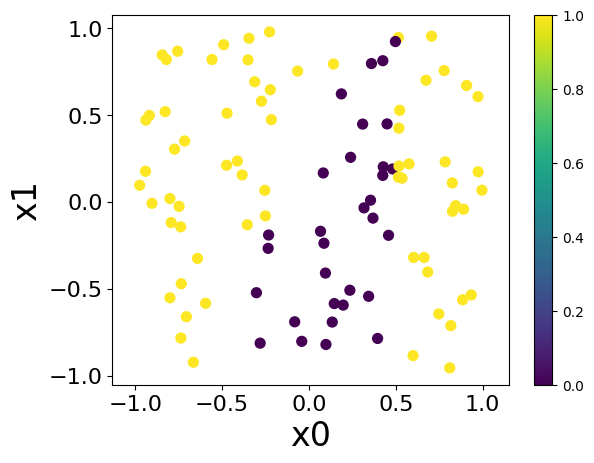

In [2]:
from plotting import plot_data_2d

plot_data_2d(x, y_gt)

b) Define a two-layer neural network by stacking two multidimensional neurons as
defined in task 2 above. Specifically, let the first layer of neurons have weights of
size (2,N) and biases of size (N,), and the second layer have weights of size (N,1)
and bias of size (1,). Make a color coded scatter plot of the output of the
randomly initialized network

In [7]:
from numpy import exp

def sigmoid(x):
    """Sigmoid function."""
    return 1 / (1 + exp(-x))

In [8]:
def dnn2(wa, ba, wb, bb, x):
    """Two-layer dense neural network for classification."""
    x_a = x
    p_a = x_a @ wa + ba
    y_a = sigmoid(p_a)

    x_b = y_a
    p_b = x_b @ wb + bb
    y_b = sigmoid(p_b)

    return y_b


In [9]:
num_neurons = 3

from numpy.random import default_rng
rng = default_rng(seed=42)
wa = rng.standard_normal(size=(2, num_neurons))
ba = rng.standard_normal(size=(num_neurons,))
wb = rng.standard_normal(size=(num_neurons, 1))
bb = rng.standard_normal(size=(1,))

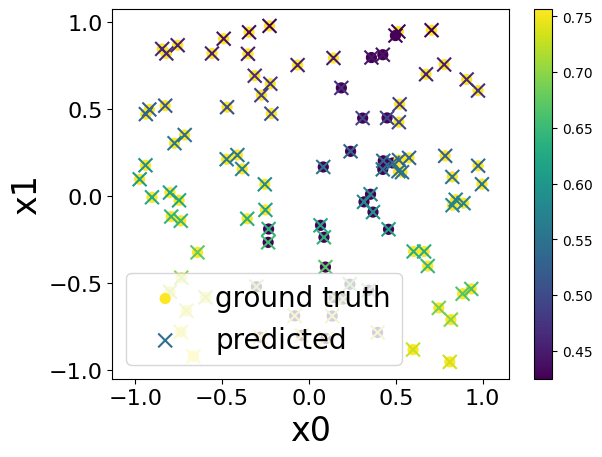

In [11]:
from plotting import plot_pred_2d
plot_pred_2d(x, y_gt, y_p=dnn2(wa, ba, wb, bb, x))

c) Modify the training loop to train this network. Now, the errors must be
backpropagated through the layers of the network. 
Where the subscript ”out” signifies that this corresponds to the final layer of the
network. Further, 𝑦⃗0 corresponds to the output from the second-to-last (which in
this case is also the first) layer of the network.
Plot, as in the previous cases, the evolution of the error and the final output of the
trained network. Hint: use 𝜂 ≈ 0.1

In [12]:
def d_sigmoid(x):
    """Derivative of sigmoid function."""
    return sigmoid(x) * (1 - sigmoid(x))

In [16]:
from numpy import reshape, sum, transpose

num_samples = len(x)
num_train_iterations = 10 ** 5
eta = 0.1
errors = []

for i in range(num_train_iterations):
    selected      = rng.integers(0, num_samples)
    x_selected    = reshape(x[selected], (1, -1))
    y_gt_selected = reshape(y_gt[selected], (1, -1))

    # Forward pass
    p_a        = x_selected @ wa + ba
    y_a        = sigmoid(p_a)

    p_b        = y_a @ wb + bb
    y_p        = sigmoid(p_b)

    # Backward pass
    error      = y_p - y_gt_selected

    delta_b    = error * d_sigmoid(p_b)
    wb         = wb - eta * delta_b * transpose(y_a)
    bb         = bb - eta * delta_b

    delta_a    = sum(wb * delta_b, axis=1) * d_sigmoid(p_a)
    wa         = wa - eta * delta_a * transpose(x_selected)
    ba         = ba - eta * delta_a

    errors.append(error[0, 0] ** 2)


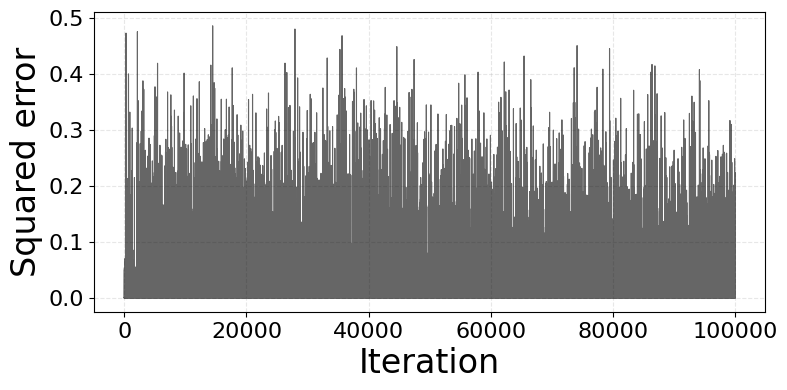

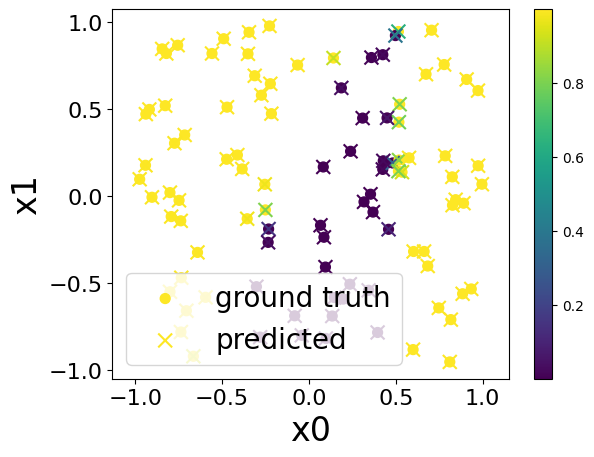

In [17]:
from plotting import plot_errors

plot_errors(errors)

plot_pred_2d(x, y_gt, y_p=dnn2(wa, ba, wb, bb, x))